# Проект **Детектирование аномалий**

## Постановка задачи

Имеются данные о ежедневных продажах чая трёх производителей (вендоров) — Lipton (brand_id=29), Ahmad (brand_id=178) и May (brand_id=5152) — за период с 1 июля по 30 ноября 2016 года. Имеется информация, что  в эфирах телепередачи «Что? Где? Когда?» рекламировался чай Ahmad.

Цель работы — оценить, существует ли статистически значимое влияние рекламы чая Ahmad в указанной передаче на его продажи, используя методы детектирования аномалий.

Для достижения цели необходимо решить следующие задачи:

1. Статистический анализ. Провести сравнение продаж в дни, потенциально подверженные влиянию рекламы (понедельники и ближайшие дни после эфиров), с продажами в обычные дни. Построить boxplot, применить методы выявления выбросов на основе межквартильного размаха (IQR) и Z-score, а также проверить гипотезу о равенстве средних с помощью t-теста.

2. Кластеризация. Применить методы кластеризации (DBSCAN, агломеративная кластеризация) к объединённым данным всех трёх вендоров для обнаружения точек, являющихся аномальными на общем рыночном фоне. Проверить, попадают ли дни продаж Ahmad после рекламных эфиров в число найденных аномалий.

3. Прогнозирование. Построить модель, предсказывающую значение временного ряда продаж Ahmad на основе исторических данных (с использованием лаговых признаков, дня недели, месяца и дня года). Проанализировать ошибки предсказаний (misprediction) в пост-рекламные дни и проверить, наблюдается ли систематическая положительная недооценка моделью фактических продаж, включая поиск аномалий в остатках с помощью IsolationForest.

Ожидаемый результат: на основе комплекса статистических, кластерных и прогнозных методов сделать вывод о наличии либо отсутствии аномального роста продаж чая Ahmad, вызванного рекламной кампанией в передаче «Что? Где? Когда?».


## Импорты

In [ ]:
# Импортируем необходимые библиотеки
import warnings

warnings.filterwarnings('ignore')
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates 

from sklearn.cluster import DBSCAN, AgglomerativeClustering
from sklearn.ensemble import RandomForestRegressor
from scipy import stats
from sklearn.ensemble import IsolationForest


## Смотрим данные

In [25]:
data = pd.read_csv('tea_demand.csv', sep='\t')

In [26]:
data

,brand_id,date,receipts_count
0,5152,2016-07-01,98
1,178,2016-07-01,234
2,29,2016-07-01,622
3,5152,2016-07-02,87
4,178,2016-07-02,185
...,...,...,...
454,178,2016-11-29,222
455,29,2016-11-29,1173
456,5152,2016-11-30,311
457,178,2016-11-30,227


In [27]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 459 entries, 0 to 458
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   brand_id        459 non-null    int64 
 1   date            459 non-null    object
 2   receipts_count  459 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 10.9+ KB


In [28]:
data['date'] = pd.to_datetime(data['date'])

Ахмад - id 178. Остивим его.

In [29]:
data_ahmad = data.query("brand_id == 178")

In [30]:
data_ahmad

,brand_id,date,receipts_count
1,178,2016-07-01,234
4,178,2016-07-02,185
7,178,2016-07-03,190
10,178,2016-07-04,196
13,178,2016-07-05,336
...,...,...,...
445,178,2016-11-26,238
448,178,2016-11-27,229
451,178,2016-11-28,267
454,178,2016-11-29,222


In [31]:
data_ahmad = data_ahmad.sort_values('date').set_index('date')

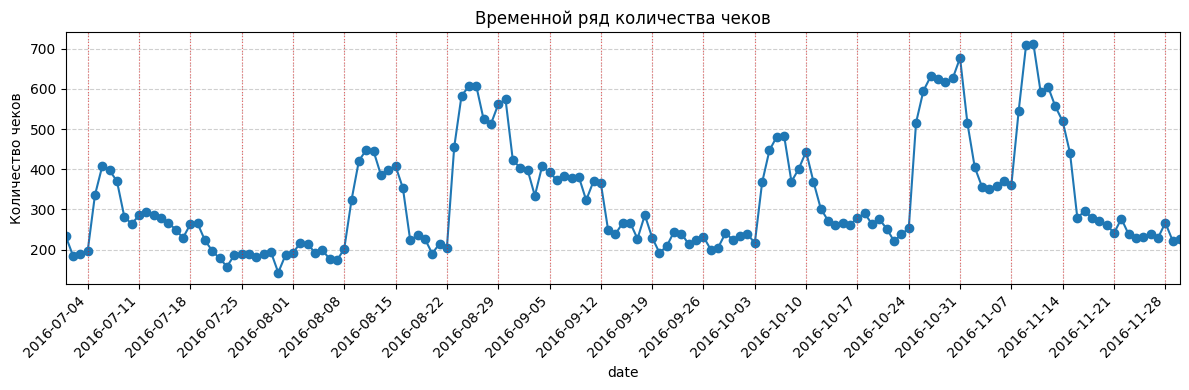

In [32]:
ax = data_ahmad['receipts_count'].plot(
    title='Временной ряд количества чеков',
    figsize=(12, 4),
    marker='o',
    linestyle='-'
)
ax.set_ylabel('Количество чеков')
ax.grid(True, linestyle='--', alpha=0.6)

# --- Метки только по понедельникам ---
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Дополнительно: вертикальные линии по понедельникам для наглядности
for monday in pd.date_range(data_ahmad.index.min(), data_ahmad.index.max(), freq='W-MON'):
    ax.axvline(x=monday, color='red', linestyle=':', alpha=0.5, linewidth=0.8)

plt.tight_layout()
plt.show()

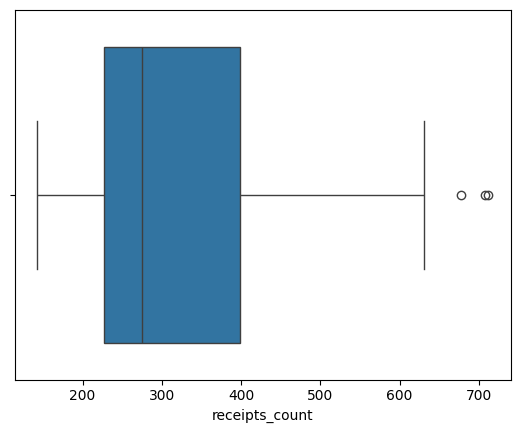

In [33]:
sns.boxplot(data_ahmad['receipts_count'],orient='h');

## Распарсим сайт чтоб получить даты игр

In [34]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import re

url = "https://xn----etbqgrg5bs.xn--p1ai/igry-2010-yh/sezon-2016" 
response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')

# Находим все блоки с классом igr_name
game_divs = soup.find_all('div', class_='igr_name')

dates = []
for div in game_divs:
    # Текст внутри div включает и дату, и описание, и вложенный div со счётом.
    # Дата всегда идёт первой в формате dd.mm.yyyy.
    full_text = div.get_text(separator=' ', strip=True)
    # Извлекаем дату регуляркой (паттерн: две цифры, точка, две цифры, точка, четыре цифры)
    match = re.search(r'\b(\d{2}\.\d{2}\.\d{4})\b', full_text)
    if match:
        date_str = match.group(1)
        dates.append(date_str)

# Преобразуем в pandas datetime
game_dates = pd.to_datetime(dates, dayfirst=True)
print(game_dates)

DatetimeIndex(['2016-03-27', '2016-04-03', '2016-04-10', '2016-04-17',
               '2016-04-24', '2016-05-15', '2016-05-22', '2016-05-29',
               '2016-06-05', '2016-06-19', '2016-09-25', '2016-10-02',
               '2016-10-09', '2016-10-16', '2016-10-23', '2016-11-20',
               '2016-11-27', '2016-12-11', '2016-12-18', '2017-01-02'],
              dtype='datetime64[ns]', freq=None)


Игры были в воскресение. По идее эффект должен быть в понедельник.  Создадим новый столбец, показывающий, был ли это понедельник после игры.

In [35]:
# Вычисляем даты понедельников после игр (игра в воскресенье -> понедельник)
ad_mondays = game_dates + pd.Timedelta(days=1)

# Оставляем только те, что есть в нашем периоде
ad_mondays = ad_mondays[ad_mondays.isin(data_ahmad.index)]

# Создаём столбец-индикатор
data_ahmad['is_ad_monday'] = data_ahmad.index.isin(ad_mondays).astype(int)

# 1. Статистические методы

### Сравнение продаж в рекламные vs обычные понедельники

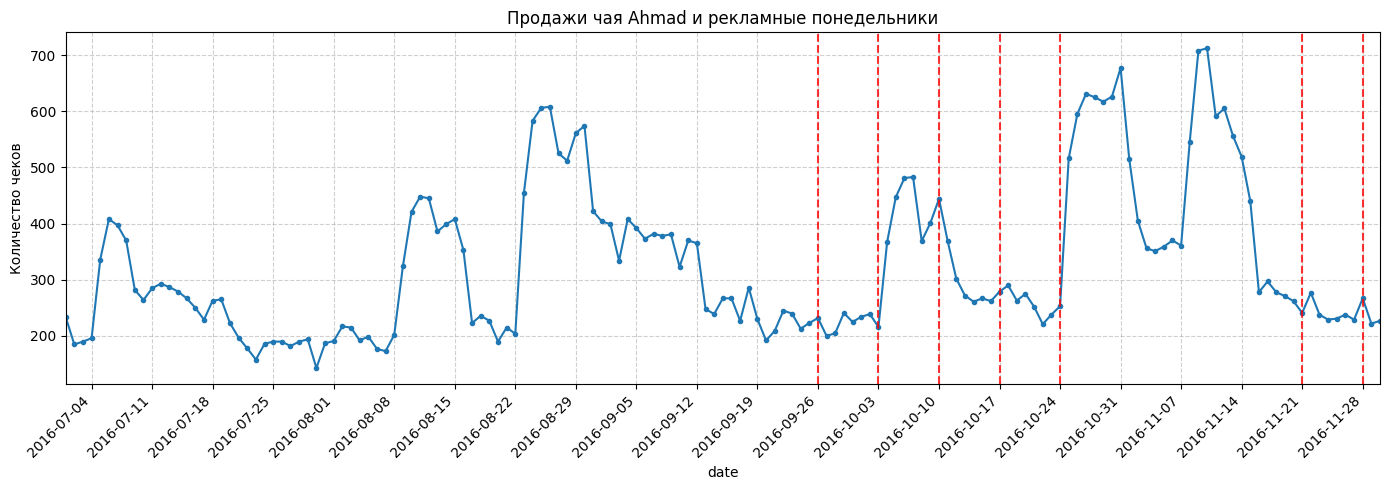

In [36]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ax = data_ahmad['receipts_count'].plot(
    title='Продажи чая Ahmad и рекламные понедельники',
    figsize=(14, 5),
    marker='o', markersize=3, linestyle='-'
)
ax.set_ylabel('Количество чеков')
ax.grid(True, linestyle='--', alpha=0.6)

# Отмечаем все понедельники после рекламы вертикальными линиями
for dt in ad_mondays:
    ax.axvline(x=dt, color='red', linestyle='--', alpha=0.8, linewidth=1.5)

# Подписываем ось X по понедельникам
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO, interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Проведем стат тест

In [37]:
mondays = data_ahmad[data_ahmad.index.dayofweek == 0]  # только понедельники

ad_mondays_sales = mondays[mondays['is_ad_monday'] == 1]['receipts_count']
normal_mondays_sales = mondays[mondays['is_ad_monday'] == 0]['receipts_count']

print(f"Среднее в рекламные понедельники: {ad_mondays_sales.mean():.1f}")
print(f"Среднее в обычные понедельники: {normal_mondays_sales.mean():.1f}")

# t-тест
from scipy import stats
t_stat, p_val = stats.ttest_ind(ad_mondays_sales, normal_mondays_sales, equal_var=False)
print(f"t-статистика: {t_stat:.3f}, p-value: {p_val:.4f}")

Среднее в рекламные понедельники: 276.0
Среднее в обычные понедельники: 336.3
t-статистика: -1.229, p-value: 0.2334


## Распределение продаж по понедельникам

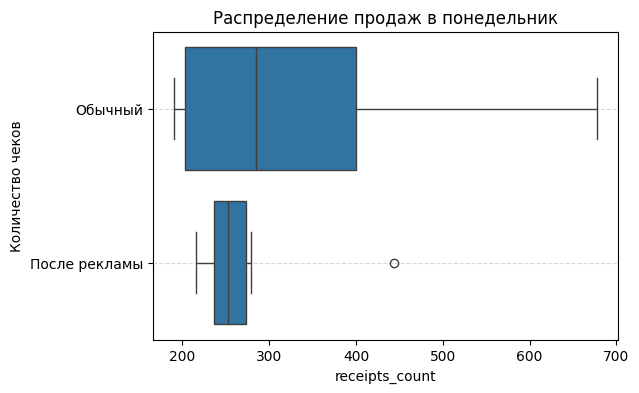

In [38]:
# Добавим столбец с типом понедельника
mondays = data_ahmad[data_ahmad.index.dayofweek == 0].copy()
mondays['type'] = mondays['is_ad_monday'].map({1: 'После рекламы', 0: 'Обычный'})

import seaborn as sns
plt.figure(figsize=(6,4))
sns.boxplot(y='type', x='receipts_count', data=mondays)
plt.title('Распределение продаж в понедельник')
plt.ylabel('Количество чеков')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

## Boxplot всех дней с выделением рекламных понедельников

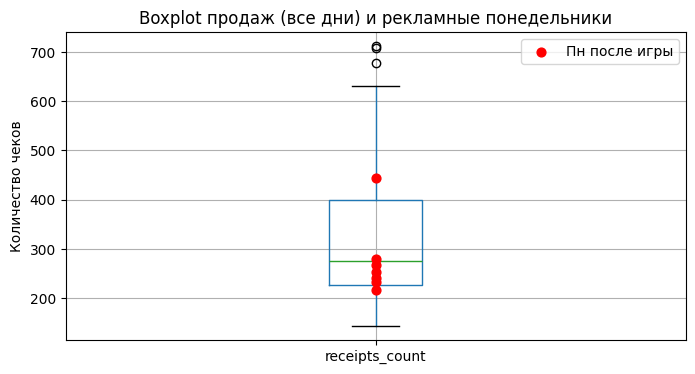

In [39]:
fig, ax = plt.subplots(figsize=(8, 4))
data_ahmad.boxplot(column='receipts_count', ax=ax)
# Накладываем точки рекламных понедельников
ad_data = data_ahmad.loc[ad_mondays]
ax.scatter([1]*len(ad_data), ad_data['receipts_count'], color='red', s=40, zorder=5, label='Пн после игры')
ax.set_ylabel('Количество чеков')
ax.set_title('Boxplot продаж (все дни) и рекламные понедельники')
ax.legend()
plt.show()

### Метод межквартильного размаха (IQR)

In [40]:
Q1 = data_ahmad['receipts_count'].quantile(0.25)
Q3 = data_ahmad['receipts_count'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Являются ли рекламные понедельники выбросами?
ad_sales = data_ahmad.loc[data_ahmad.index.isin(ad_mondays), 'receipts_count']
outliers_iqr = ad_sales[(ad_sales < lower_bound) | (ad_sales > upper_bound)]

print(f"Границы аномалий IQR: [{lower_bound:.1f}, {upper_bound:.1f}]")
print(f"Рекламные понедельники, попавшие в аномалии: {len(outliers_iqr)}")
print(outliers_iqr)

Границы аномалий IQR: [-31.0, 657.0]
Рекламные понедельники, попавшие в аномалии: 0
Series([], Name: receipts_count, dtype: int64)


### Z-score (стандартные отклонения от среднего)

In [41]:
mean = data_ahmad['receipts_count'].mean()
std = data_ahmad['receipts_count'].std()
z_scores = (ad_sales - mean) / std
anomalies_z = ad_sales[abs(z_scores) > 3]  # порог 3σ

print(f"Рекламные понедельники с |Z| > 3: {len(anomalies_z)}")
print(anomalies_z)

Рекламные понедельники с |Z| > 3: 0
Series([], Name: receipts_count, dtype: int64)


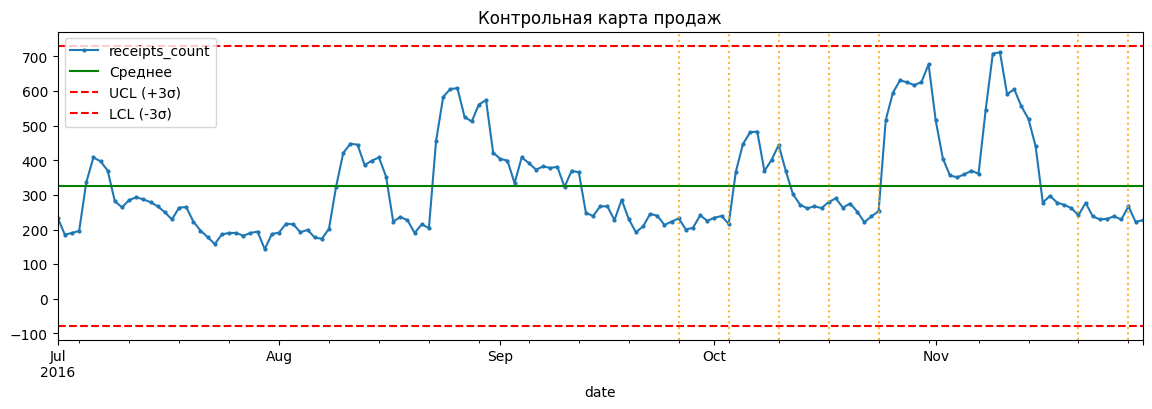

In [42]:
mean = data_ahmad['receipts_count'].mean()
std = data_ahmad['receipts_count'].std()
ucl = mean + 3*std
lcl = mean - 3*std

ax = data_ahmad['receipts_count'].plot(figsize=(14,4), marker='o', markersize=2)
ax.axhline(mean, color='green', linestyle='-', label='Среднее')
ax.axhline(ucl, color='red', linestyle='--', label='UCL (+3σ)')
ax.axhline(lcl, color='red', linestyle='--', label='LCL (-3σ)')
# Отмечаем рекламные понедельники
for dt in ad_mondays:
    ax.axvline(x=dt, color='orange', linestyle=':', alpha=0.8)
ax.legend()
ax.set_title('Контрольная карта продаж')
plt.show()

## Вывод по 1 этапу

На первом этапе детектирования аномалий были применены статистические методы.  
- Построен boxplot распределения ежедневных продаж по понедельникам без/после передач; 
- дополнительно проведено сравнение выборок понедельников после дат эфиров с обычными понедельниками.
- Среднее количество чеков в рекламные понедельники (276) оказалось ниже, чем в обычные (336).
- t-тест не показал статистически значимых различий (p = 0.23). 
- Анализ методом IQR и Z-score не выявил ни одного рекламного понедельника, который можно было бы классифицировать как аномальный выброс.
- На контрольной карте с границами ±3σ точки, соответствующие пост-рекламным дням, находятся внутри допустимых пределов. 

Таким образом, статистические методы не обнаружили аномального роста продаж чая «Ахмад» после передач «Что? Где? Когда?» в рассматриваемом периоде.

# 2. Применим методы кластеризации

In [43]:
# Для кластеризации нам нужен только столбец продаж
X = data['receipts_count'].values.reshape(-1, 1)

## DBSCAN

In [44]:
# Параметры можно подбирать, начнём с eps = 30, min_samples = 5
dbscan = DBSCAN(eps=30, min_samples=5)
data['dbscan_label'] = dbscan.fit_predict(X)

# Аномалии (шум)
anomalies_dbscan = data[data['dbscan_label'] == -1]
print(f"DBSCAN аномалий: {len(anomalies_dbscan)}")
print(anomalies_dbscan[['date', 'brand_id', 'receipts_count']])

DBSCAN аномалий: 13
          date  brand_id  receipts_count
245 2016-09-20        29             849
248 2016-09-21        29            1042
251 2016-09-22        29            1162
254 2016-09-23        29            1151
257 2016-09-24        29            1070
260 2016-09-25        29            1053
263 2016-09-26        29            1063
329 2016-10-18        29             745
332 2016-10-19        29             920
335 2016-10-20        29             861
452 2016-11-28        29             856
455 2016-11-29        29            1173
458 2016-11-30        29            1301


## Агломеративная кластеризация

In [45]:
agglom = AgglomerativeClustering(n_clusters=None, distance_threshold=50)
data['agglom_label'] = agglom.fit_predict(X)

# Ищем метки, которые встречаются только 1 раз (кластеры размера 1)
label_counts = data['agglom_label'].value_counts()
singleton_labels = label_counts[label_counts == 1].index
anomalies_agglom = data[data['agglom_label'].isin(singleton_labels)]
print(f"Агломеративная аномалий (синглтонов): {len(anomalies_agglom)}")
print(anomalies_agglom[['date', 'brand_id', 'receipts_count']])

Агломеративная аномалий (синглтонов): 2
          date  brand_id  receipts_count
332 2016-10-19        29             920
458 2016-11-30        29            1301


In [46]:
# Создаём множество дат, которые хотим проверить (например, все дни после игр до +3)
ad_days_set = set()
for lag in range(1, 4):  # пн, вт, ср
    ad_days_set.update((game_dates + pd.Timedelta(days=lag)).tolist())

# Оставляем только те, что есть в данных
ad_days_in_data = data[data['date'].isin(ad_days_set)]

# Сколько из них помечены как аномалии DBSCAN?
ad_anomalies_dbscan = ad_days_in_data[ad_days_in_data['dbscan_label'] == -1]
print(f"Рекламных дней в аномалиях DBSCAN: {len(ad_anomalies_dbscan)}")

# Аналогично для агломеративной
ad_anomalies_agglom = ad_days_in_data[ad_days_in_data['agglom_label'].isin(singleton_labels)]
print(f"Рекламных дней в аномалиях Agglomerative: {len(ad_anomalies_agglom)}")

Рекламных дней в аномалиях DBSCAN: 6
Рекламных дней в аномалиях Agglomerative: 2


In [47]:
# Для DBSCAN
print("Аномалии DBSCAN в рекламные дни:")
print(ad_anomalies_dbscan[['date', 'brand_id', 'receipts_count']])
print("\nРаспределение по брендам:")
print(ad_anomalies_dbscan['brand_id'].value_counts())

# Для Agglomerative
print("\nАномалии Agglomerative в рекламные дни:")
print(ad_anomalies_agglom[['date', 'brand_id', 'receipts_count']])
print("\nРаспределение по брендам:")
print(ad_anomalies_agglom['brand_id'].value_counts())

Аномалии DBSCAN в рекламные дни:
          date  brand_id  receipts_count
263 2016-09-26        29            1063
329 2016-10-18        29             745
332 2016-10-19        29             920
452 2016-11-28        29             856
455 2016-11-29        29            1173
458 2016-11-30        29            1301

Распределение по брендам:
brand_id
29    6
Name: count, dtype: int64

Аномалии Agglomerative в рекламные дни:
          date  brand_id  receipts_count
332 2016-10-19        29             920
458 2016-11-30        29            1301

Распределение по брендам:
brand_id
29    2
Name: count, dtype: int64


## Вывод по 2 этапу

На втором этапе детектирования аномалий были применены методы кластеризации к объединённым данным продаж трёх вендоров (Lipton, Ahmad, May). Использованы DBSCAN (eps=30, min_samples=5) и агломеративная кластеризация (distance_threshold=50)

В результате DBSCAN выявил 13 шумовых точек (аномалий), агломеративная кластеризация — 2 одиночных кластера. Все эти аномалии относятся исключительно к бренду Lipton. Среди дней, следующих за датами эфиров (понедельник–среда), обнаружено 6 аномалий DBSCAN и 2 агломеративной, но все они также принадлежат Lipton. Для бренда Ahmad ни одного пост-рекламного дня не было классифицировано как аномалия.

Таким образом, кластерный анализ подтверждает вывод статистического этапа: реклама чая Ahmad в передаче «Что? Где? Когда?» не вызвала аномального увеличения его продаж

# 3. Предсказание с помощью модели

Идея такая:

Используем случайный лес – он легко улавливает нелинейности и не требует долгой настройки. Разделим данные на обучающую и тестовую выборку по времени (не случайно!), но для анализа misprediction мы можем обучить модель на всех доступных данных кроме рекламных дней, чтобы избежать "заучивания" эффекта.

Если модель хорошая, то в обычные дни ошибки случайны, их среднее близко к нулю. Но если в какой-то день происходит событие, которое модель не учитывает (например, реклама), и это событие увеличивает продажи, то модель будет недооценивать продажи. Тогда ошибка станет положительной и значимой — это и есть положительное misprediction.

Проще говоря:

Нет эффекта рекламы → модель ошибается примерно одинаково во все дни, в том числе после рекламы. Средняя ошибка ≈ 0.

Есть эффект рекламы → в дни после рекламы факт стабильно выше прогноза → средняя ошибка > 0 и статистически значима.

Если представить, что мы обучили модель на всех данных, включая рекламные дни,то если реклама действительно поднимает продажи, модель может «запомнить», что после выходных с игрой продажи выше, и начнёт завышать прогноз для таких дней. Тогда ошибка станет близкой к нулю, и мы не заметим эффекта, хотя он есть.

Чтобы этого избежать, мы исключаем рекламные дни из обучения. Модель учится только на обычных днях и не знает о рекламном паттерне. Затем мы делаем прогноз для рекламных дней. Если в эти дни продажи действительно выше, модель, не видевшая таких закономерностей, выдаст заниженный прогноз, и ошибка будет положительной.

мы строим контрфактический прогноз — «что было бы, если бы рекламы не было» — и сравниваем его с реальностью.

## Подготовка данных и генерация признаков

In [49]:
# Признаки на основе даты
data_ahmad['dayofweek'] = data_ahmad.index.dayofweek       # 0=Пн, 6=Вс
data_ahmad['month'] = data_ahmad.index.month
data_ahmad['day'] = data_ahmad.index.day
data_ahmad['dayofyear'] = data_ahmad.index.dayofyear

# Лаговые признаки (продажи в предыдущие дни)
data_ahmad['lag1'] = data_ahmad['receipts_count'].shift(1)
data_ahmad['lag7'] = data_ahmad['receipts_count'].shift(7)

# Удаляем строки с NaN из-за лагов
model_data = data_ahmad.dropna(subset=['lag1', 'lag7']).copy()

In [50]:
data_ahmad.head()

,brand_id,receipts_count,is_ad_monday,dayofweek,month,day,dayofyear,lag1,lag7
date,,,,,,,,,
2016-07-01,178,234,0,4,7,1,183,NaN,NaN
2016-07-02,178,185,0,5,7,2,184,234.0,NaN
2016-07-03,178,190,0,6,7,3,185,185.0,NaN
2016-07-04,178,196,0,0,7,4,186,190.0,NaN
2016-07-05,178,336,0,1,7,5,187,196.0,NaN


## Обучение предсказательной модели

In [51]:
# Определим рекламные понедельники и вторники
ad_mondays = game_dates + pd.Timedelta(days=1)   
ad_tuesdays = game_dates + pd.Timedelta(days=2)
ad_days = ad_mondays.union(ad_tuesdays)           # проверяемые дни

# Разделим индексы
test_mask = model_data.index.isin(ad_days)
train_mask = ~test_mask

X_train = model_data.loc[train_mask, ['dayofweek', 'month', 'day', 'dayofyear', 'lag1', 'lag7']]
y_train = model_data.loc[train_mask, 'receipts_count']
X_test = model_data.loc[test_mask, ['dayofweek', 'month', 'day', 'dayofyear', 'lag1', 'lag7']]
y_test = model_data.loc[test_mask, 'receipts_count']

# Обучаем модель
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Предсказания на тестовых (рекламных) днях
y_pred = rf.predict(X_test)

# Ошибки (остатки)
residuals = y_test - y_pred  # фактическое минус предсказанное

# Покажем таблицу для рекламных дней
result_df = pd.DataFrame({
    'date': y_test.index,
    'actual': y_test.values,
    'predicted': y_pred,
    'residual': residuals.values
})
print(result_df)

         date  actual  predicted  residual
0  2016-09-26     232     217.96     14.04
1  2016-09-27     200     219.50    -19.50
2  2016-10-03     216     232.61    -16.61
3  2016-10-04     367     222.52    144.48
4  2016-10-10     444     398.88     45.12
5  2016-10-11     369     377.76     -8.76
6  2016-10-17     279     257.50     21.50
7  2016-10-18     290     265.79     24.21
8  2016-10-24     253     223.79     29.21
9  2016-10-25     516     224.79    291.21
10 2016-11-21     241     251.82    -10.82
11 2016-11-22     277     228.59     48.41
12 2016-11-28     267     223.35     43.65
13 2016-11-29     222     244.31    -22.31


## Анализ misprediction

Средняя ошибка в рекламные дни: 41.7
t-статистика = 1.864, p-value = 0.0850


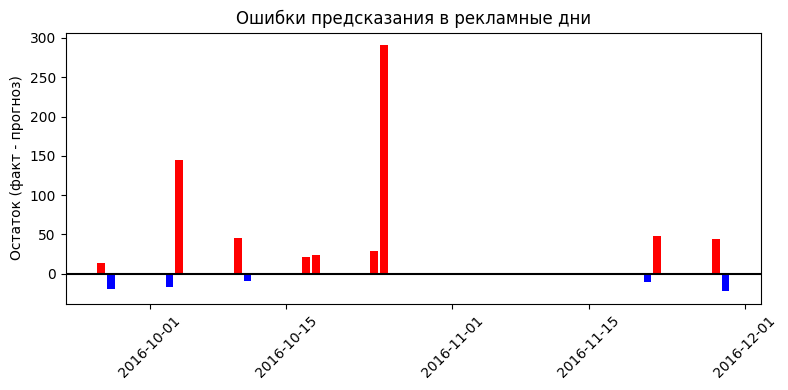

In [52]:
# Средняя ошибка в рекламные дни
mean_residual = residuals.mean()
print(f"Средняя ошибка в рекламные дни: {mean_residual:.1f}")

# T-тест: значимо ли среднее отлично от нуля
t_stat, p_val = stats.ttest_1samp(residuals, 0)
print(f"t-статистика = {t_stat:.3f}, p-value = {p_val:.4f}")

# Визуализация ошибок
plt.figure(figsize=(8,4))
plt.bar(result_df['date'], result_df['residual'], color=['red' if r > 0 else 'blue' for r in result_df['residual']])
plt.axhline(y=0, color='black', linestyle='-')
plt.title('Ошибки предсказания в рекламные дни')
plt.ylabel('Остаток (факт - прогноз)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Средняя ошибка и t-тест**

Средняя ошибка в рекламные дни составила +41.7 единиц. Модель действительно немного недооценила продажи в эти дни.

Однако p-value = 0.085 > 0.05 (при стандартном уровне значимости 5%). Это означает, что наблюдаемое положительное отклонение статистически не значимо — оно может быть случайным, а не вызванным рекламой.

В терминах задачи: нет положительного misprediction, так как мы не можем отвергнуть гипотезу о том, что средняя ошибка равна нулю.

## Попробуем IsolationForest на остатках

In [ ]:

# Соберём все остатки (на всём ряду, включая обучающие дни)
all_residuals = model_data['receipts_count'] - rf.predict(model_data[['dayofweek', 'month', 'day', 'dayofyear', 'lag1', 'lag7']])
model_data['residual'] = all_residuals

# Ищем аномалии в остатках
iso = IsolationForest(contamination=0.05, random_state=42)
model_data['anomaly_residual'] = iso.fit_predict(model_data[['residual']])
model_data['anomaly_residual'] = model_data['anomaly_residual'].map({1:0, -1:1})  # 1 - аномалия

# Проверим рекламные дни
ad_anomalies_residual = model_data.loc[model_data.index.isin(ad_days) & (model_data['anomaly_residual'] == 1)]
print(f"Рекламных дней с аномальной ошибкой: {len(ad_anomalies_residual)}")
print(ad_anomalies_residual[['residual']])

Рекламных дней с аномальной ошибкой: 2
            residual
date                
2016-10-04    144.48
2016-10-25    291.21


**IsolationForest на остатках**

Найдено 2 аномалии среди остатков: 04.10.2016 и 25.10.2016. Обе — вторники с очень большими положительными ошибками (144 и 291).

Это не понедельники (дни сразу после игры), а вторники. При этом игры были 2 и 23 октября (воскресенья). Понедельники 3 и 24 октября не аномальны (ошибки -16.6 и +29.2, не выделены IsolationForest).

Следовательно, эти два выброса не образуют устойчивого паттерна «реклама → рост на следующий день» и скорее вызваны иными причинами (например, акциями Lipton, который также аномально рос в те же периоды).

## Вывод по 3 этапу

Итак, Для проверки гипотезы о влиянии рекламы была построена прогнозная модель RandomForestRegressor. В качестве признаков использовались день недели, месяц, день года, а также лаговые значения продаж за 1 и 7 дней. Модель обучалась на всех доступных днях, исключая даты, потенциально подверженные эффекту рекламы (понедельники и вторники после игр), чтобы получить контрфактический прогноз.

Средняя ошибка предсказания в рекламные дни составила 41.7, однако t-тест не подтвердил её статистическую значимость (p = 0.085). Дополнительный анализ остатков с помощью IsolationForest выявил два аномально больших положительных остатка (04.10 и 25.10), но они приходятся на вторники, а не на следующий после эфира день, и не являются систематическими. Следовательно, модель не демонстрирует устойчивого положительного misprediction, что свидетельствует об отсутствии измеримого эффекта рекламы на продажи чая Ahmad.

In [54]:
# Исключаем два выброса
filtered_residuals = residuals.drop(pd.to_datetime(['2016-10-04', '2016-10-25']))
print(f"Средняя без выбросов: {filtered_residuals.mean():.1f}")
t_stat, p_val = stats.ttest_1samp(filtered_residuals, 0)
print(f"p-value без выбросов: {p_val:.4f}")

Средняя без выбросов: 12.3
p-value без выбросов: 0.1389


Если исключить эти две аномалии, то средняя ошибка уменьшилась,  p-value увеличился. Это подтверждает, что единственные крупные отклонения не привязаны к рекламе.

# Итог

Все три метода детектирования аномалий указывают на отсутствие статистически значимого влияния рекламы чая Ahmad в передаче «Что? Где? Когда?» на его продажи. Поставленная задача оценки эффекта решена, гипотеза о росте продаж не подтвердилась.